Found 50 PMIDs


,PMID,title,journal,date,year,abstract,mesh
0,38409030,PARP inhibitor era in ovarian cancer treatment...,Journal of ovarian research,2024 Feb 26,2024.0,BACKGROUND: Ovarian cancer is the eighth leadi...,Humans; Female; Poly(ADP-ribose) Polymerase In...
1,38778348,PARP1-DOT1L transcription axis drives acquired...,Molecular cancer,2024 May 22,2024.0,BACKGROUND: Poly (ADP-ribose) polymerase inhib...,Humans; *Ovarian Neoplasms/drug therapy/geneti...
2,37702443,KLF5 Promotes Tumor Progression and Parp Inhib...,"Advanced science (Weinheim, Baden-Wurttemberg,...",2023 Nov,2023.0,One major characteristic of tumor cells is the...,Humans; Female; Poly(ADP-ribose) Polymerase In...
3,37737434,Treatment of Ovarian Cancer Beyond PARP Inhibi...,Drugs,2023 Oct,2023.0,Ovarian cancer is the leading cause of gynecol...,Female; Humans; *Poly(ADP-ribose) Polymerase I...
4,35859118,PBK drives PARP inhibitor resistance through t...,Experimental & molecular medicine,2022 Jul,2022.0,Resistance to PARP inhibitors (PARPi) remains ...,*Antineoplastic Agents/pharmacology/therapeuti...


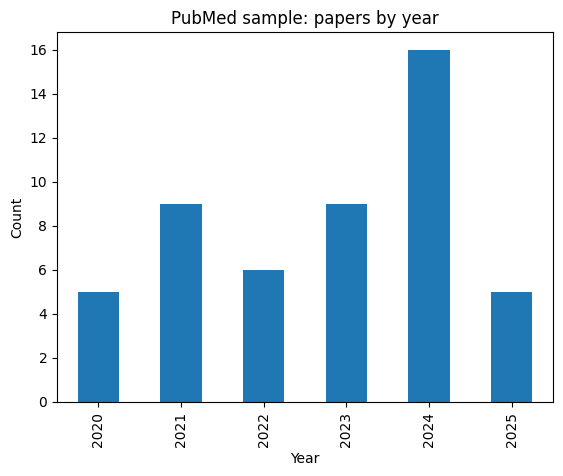

,term,mean_tfidf
20,parpi,0.222787
1,cancer,0.220572
15,ovarian,0.191882
17,parp,0.190895
16,ovarian cancer,0.183879
26,resistance,0.175729
12,inhibitors,0.144612
11,inhibitor,0.135997
28,treatment,0.118388
18,parp inhibitor,0.115664


Wrote: pubmed_sample.csv and pubmed_sample.json


In [ ]:
# PubMed Mini Scan (toy systematic scan) 
# pip install biopython pandas matplotlib scikit-learn

from Bio import Entrez
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# 1) Configure Entrez (NCBI asks for an email; an API key is optional but recommended for heavier usage)
Entrez.email = "YOUR_EMAIL@domain.com"
# Entrez.api_key = "YOUR_NCBI_API_KEY"  # optional

QUERY = '(parp inhibitor) AND (ovarian cancer) AND ("2020"[dp] : "2026"[dp])'
N = 50  # keep toy-sized for a portfolio demo

def pubmed_search(query: str, retmax: int = 50):
    handle = Entrez.esearch(db="pubmed", term=query, retmax=retmax, sort="relevance")
    res = Entrez.read(handle)
    handle.close()
    return res["IdList"]

def pubmed_fetch_details(pmids):
    # Fetch MEDLINE records for convenient parsing
    handle = Entrez.efetch(db="pubmed", id=",".join(pmids), rettype="medline", retmode="text")
    text = handle.read()
    handle.close()
    return text

def parse_medline_block(medline_text: str):
    """
    Minimal MEDLINE parser for a toy demo:
    - Captures PMID, TI (title), JT (journal), DP (date), AB (abstract), MH (MeSH)
    """
    records = []
    cur = {"MH": []}
    last_key = None

    for line in medline_text.splitlines():
        if not line.strip():
            continue

        # New field line (e.g., "PMID- 12345")
        m = re.match(r"^([A-Z]{2,4})\s*-\s*(.*)$", line)
        if m:
            key, val = m.group(1), m.group(2).strip()
            last_key = key

            if key == "PMID":
                # flush old record if it exists
                if "PMID" in cur:
                    records.append(cur)
                    cur = {"MH": []}
                cur["PMID"] = val
            elif key in {"TI", "JT", "DP", "AB"}:
                cur[key] = val
            elif key == "MH":
                cur["MH"].append(val)
            else:
                # ignore other fields for this mini notebook
                pass
        else:
            # Continuation line (starts with spaces)
            cont = line.strip()
            if last_key in {"TI", "AB"}:
                cur[last_key] = (cur.get(last_key, "") + " " + cont).strip()
            elif last_key == "MH":
                # occasionally MeSH can wrap; append to last MeSH term
                if cur["MH"]:
                    cur["MH"][-1] = (cur["MH"][-1] + " " + cont).strip()

    if "PMID" in cur:
        records.append(cur)

    df = pd.DataFrame(records)
    df["year"] = df["DP"].str.extract(r"(\d{4})").astype(float)
    df["mesh"] = df["MH"].apply(lambda xs: "; ".join(xs) if isinstance(xs, list) else "")
    df = df.rename(columns={"TI": "title", "JT": "journal", "AB": "abstract", "DP": "date"})
    return df[["PMID", "title", "journal", "date", "year", "abstract", "mesh"]]

# 2) Run the workflow
pmids = pubmed_search(QUERY, retmax=N)
print(f"Found {len(pmids)} PMIDs")

medline_text = pubmed_fetch_details(pmids)
df = parse_medline_block(medline_text)

# 3) Quick EDA
display(df.head(5))

year_counts = df["year"].dropna().astype(int).value_counts().sort_index()
year_counts.plot(kind="bar")
plt.title("PubMed sample: papers by year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

# 4) Lightweight keyword signal (TF-IDF over titles+abstracts)
corpus = (df["title"].fillna("") + ". " + df["abstract"].fillna("")).tolist()
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=30,
    ngram_range=(1, 2),
)
X = vectorizer.fit_transform(corpus)
top_terms = pd.Series(vectorizer.get_feature_names_out(), index=range(len(vectorizer.get_feature_names_out())))
tfidf_means = X.mean(axis=0).A1
top_tfidf = pd.DataFrame({"term": vectorizer.get_feature_names_out(), "mean_tfidf": tfidf_means}).sort_values("mean_tfidf", ascending=False)

display(top_tfidf.head(15))

# 5) Export a curated sample (your portfolio artifact)
out_csv = "pubmed_sample.csv"
out_json = "pubmed_sample.json"
df.to_csv(out_csv, index=False)
df.to_json(out_json, orient="records", indent=2)

print("Wrote:", out_csv, "and", out_json)